# Lab 06 : Proximal Policy Optimization (PPO) for cartpole - solution

This notebook provides a practical implementation of the Proximal Policy Optimization (PPO) algorithm for solving the reinforcement learning task of cartpole stabilization (cartpole is equivalent to MNIST for RL).

Goal: To train a reinforcement learning agent to achieve optimal performance in an environment by learning a stable and efficient policy through the PPO clip objective.

Implement: A custom PPO architecture featuring an Actor-Critic network, a transition buffer for experience replay, and a training loop that uses generalized advantage estimation and policy clipping to prevent large, destructive updates.

In [1]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    !pip install 'gymnasium[classic_control]' 
    !pip install gym-notebook-wrapper
    

In [2]:
# Libraries
import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical
import time
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
import gymnasium as gym 


## Define (simplest) classes of policy/actor network and value/critic network


In [3]:
# class of policy/actor network
#  policy function : from state to probability of actions
#                    e.g. cartpole, state = 4-dim position, actions = {move left, move right}
class PolicyNetwork(nn.Module):
    def __init__(self, net_parameters):
        super().__init__()
        self.linear1 = nn.Linear(net_parameters['input_dim'], net_parameters['hidden_dim'])
        self.linear2 = nn.Linear(net_parameters['hidden_dim'], net_parameters['hidden_dim'])
        self.linear3 = nn.Linear(net_parameters['hidden_dim'], 2) # two actions = {left, right}
    def forward(self, x):
        x = torch.relu(self.linear1(x))
        x = torch.relu(self.linear2(x))
        action_score = self.linear3(x) # size=[T,2]
        action_prob = torch.softmax(action_score, dim=1) # size=[T,2]
        return action_prob

# class of value/critic network
#  value function : from state to value, with value = total (discarded) reward at the end of episode
#                    i.e. how much reward the agent is predicted to receive at the end of episode from the current state
#                    e.g. cartpole, value = (approximately) length to the end of episode
class ValueNetwork(nn.Module):
    def __init__(self, net_parameters):
        super().__init__()
        self.linear1 = nn.Linear(net_parameters['input_dim'], net_parameters['hidden_dim'])
        self.linear2 = nn.Linear(net_parameters['hidden_dim'], net_parameters['hidden_dim'])
        self.linear3 = nn.Linear(net_parameters['hidden_dim'], 1) # scalar value
    def forward(self, x):
        x = torch.relu(self.linear1(x))
        x = torch.relu(self.linear2((x)))
        value_score = self.linear3((x))
        return value_score

# compute number of network parameters
def number_param(net):
    nb_param = 0
    for param in net.parameters():
        nb_param += param.numel()
    return nb_param

# network parameters
net_parameters = {}
net_parameters['input_dim'] = 4 # 4-dim position of cartpole
net_parameters['hidden_dim'] = 64
net_policy = PolicyNetwork(net_parameters)
net_value = ValueNetwork(net_parameters)
print('num_net_policy_parameters: %d' % number_param(net_policy) )
print('num_net_value_parameters: %d' % number_param(net_value) )


num_net_policy_parameters: 4610
num_net_value_parameters: 4545


## Rollout one episode


In [4]:
# rollout an episode :
# s_0 => a_0 ~ policy_net(s_0) => r_0, s_1 => a_1 ~ policy_net(s_1) => r_1, s_2 => ...
#                             ... => s_t => a_t ~ policy_net(s_t) => r_t, s_t+1 => ... => end of episode at t=T-1
def rollout_episode(env, net_policy, net_value):
    # t = [0, 1, 2, ..., T-1] with initial t=0, T is the episode length, and thus final t=T-1
    # states = [s_0, s_1, s_2, ..., s_T-1] 
    # next_states = [s_1, s_2, s_3, ..., s_T] 
    # actions = [a_0, a_1, a_2, ..., a_T-1] 
    # rewards = [r_0, r_1, r_2, ..., r_T-1], reward r_t=1 for all t until end of episode
    # log_probs = [log p_0, log p_1, ..., log p_T-1] 
    # values = [V_0, V_1, V_2, ..., V_T-1] 
    # dones = [d_0=0, d_1=0, d_2=0, ..., d_T-2=0, d_T-1=1] for last t=T-1
    net_policy.eval()
    net_value.eval()
    states = torch.tensor([]); next_states=torch.tensor([]); actions=torch.tensor([]).long(); rewards=torch.tensor([]);
    log_probs=torch.tensor([]); values=torch.tensor([]); dones=torch.tensor([]).long()
    state, info = env.reset() # initial state from the environment
    max_t = 1000 # rollout one episode up to 1000 time steps
    for t in range(max_t):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)    # state=s_t, size=[1,4]

        # Apply "net_policy" to the current state to get the probability over the actions (left or right moves)
        # Input  : state_pytorch, size=[1,4]
        # Output : action_probs, size=[1,2]
        # COMPLETE HERE
        action_probs = net_policy(state_pytorch) # apply policy net to state, policy_net(s_t) and get probability of actions, size=[1,2]
        # COMPLETE HERE

        # Sample next action from the probability of actions using Bernouilli distribution
        # Hint : You may use "torch.multinomial(probabilities, num_samples)" to sample the action
        # COMPLETE HERE
        action = torch.multinomial(action_probs, num_samples=1).view(1) # sample action a_t with Bernouilli distribution, size=[1]
        # COMPLETE HERE
        
        log_prob = torch.log(action_probs[:,action]).view(1).detach()   # get log probability log p_t of the sampled action, size=[1]
        next_state, reward, terminated, truncated, info = env.step(action.item()) # get next state s_t+1 (len=[4]) and reward r_t (len=[1]) from environment
        done = terminated or truncated # indicator of end of episode, done=True if end and False otherwise
        done_mask = 1 if done else 0 # mask=1 if done=True, 0 otherwise
        value = net_value(state_pytorch).detach() # apply value function and get value=V(x_t)=V_t (estimated discounted reward)
        # collect episode data in pytorch format for training
        states = torch.cat( (states, state_pytorch), dim=0)                  # size=[t+1,4]
        next_states = torch.cat( (next_states, torch.tensor(next_state).unsqueeze(0)), dim=0) # size=[t+1,4]
        actions = torch.cat( (actions, action), dim=0)                       # size=[t+1]
        rewards = torch.cat( (rewards, torch.tensor(reward).view(1)), dim=0) # size=[t+1]
        log_probs = torch.cat( (log_probs, log_prob), dim=0)                 # size=[t+1]
        values = torch.cat( (values, value.view(1) ), dim=0)                 # size=[t+1]
        dones = torch.cat( (dones, torch.tensor(done_mask).view(1)), dim=0)  # size=[t+1]
        state = next_state                                                   # update old state to new state
        if done or t==max_t-1:   # if end of episode from environment or reach maximum episode length
            episode_length = t+1 # length of episode as we start at t=0
            break
    return episode_length, states, next_states, actions, rewards, log_probs, values, dones

# test one episode
env = gym.make('CartPole-v1')
episode_length, states, next_states, actions, rewards, log_probs, values, dones = rollout_episode(env, net_policy, net_value)
print('episode_length',episode_length)
print('states',states,states.size())
print('next_states',next_states,next_states.size())
print('actions',actions,actions.size())
print('rewards',rewards,rewards.size())
print('log_probs',log_probs,log_probs.size())
print('values',values,values.size())
print('dones',dones,dones.size())


episode_length 14
states tensor([[-0.0259,  0.0239, -0.0444, -0.0233],
        [-0.0254, -0.1705, -0.0448,  0.2551],
        [-0.0288, -0.3650, -0.0397,  0.5333],
        [-0.0361, -0.5595, -0.0291,  0.8132],
        [-0.0473, -0.3640, -0.0128,  0.5115],
        [-0.0546, -0.5590, -0.0026,  0.8001],
        [-0.0658, -0.7540,  0.0134,  1.0920],
        [-0.0809, -0.5591,  0.0353,  0.8036],
        [-0.0921, -0.7547,  0.0514,  1.1072],
        [-0.1072, -0.9504,  0.0735,  1.4155],
        [-0.1262, -1.1464,  0.1018,  1.7302],
        [-0.1491, -0.9526,  0.1364,  1.4709],
        [-0.1681, -1.1491,  0.1658,  1.8029],
        [-0.1911, -0.9561,  0.2019,  1.5660]]) torch.Size([14, 4])
next_states tensor([[-0.0254, -0.1705, -0.0448,  0.2551],
        [-0.0288, -0.3650, -0.0397,  0.5333],
        [-0.0361, -0.5595, -0.0291,  0.8132],
        [-0.0473, -0.3640, -0.0128,  0.5115],
        [-0.0546, -0.5590, -0.0026,  0.8001],
        [-0.0658, -0.7540,  0.0134,  1.0920],
        [-0.0809, -0.5

## Train policy network and value network


Epoch: 199, time: 18.3844, train_loss: 285.7845, mean_episode_length: 951.0500


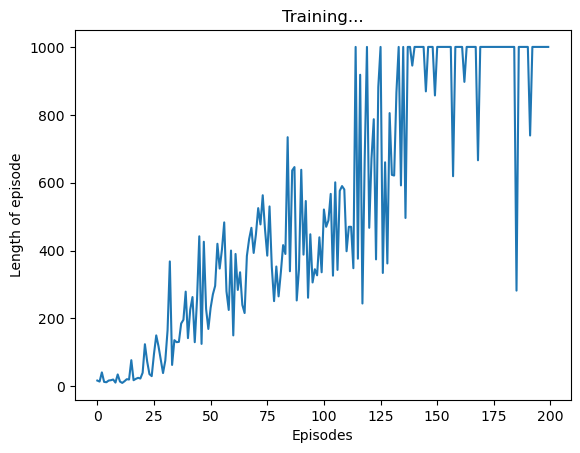

In [5]:
# train the policy and value networks with one episode
def train_policy_value_networks(opt_parameters, net_policy, net_value, optimizer_policy, optimizer_value, \
                                states, next_states, actions, rewards, log_probs, values, dones):

    # optimization parameters
    gamma = opt_parameters['gamma']
    beta = opt_parameters['beta']
    num_iter_value_loss = opt_parameters['num_iter_value_loss']
    num_iter_policy_loss = opt_parameters['num_iter_policy_loss']
    clip_value = opt_parameters['clip_value']
    entropy_value = opt_parameters['entropy_value']

    ########################################
    # Update value network
    ########################################
    
    #  Step 1 : Compute discounted rewards at each time t for the whole episode
    discounted_rewards = [] # discounted rewards
    discounted_reward_t_plus_one = 0.0 # r_t+1=r_T=0 (end-of-episode, no more reward) for t=T-1, T=length of episode
    for r_t in rewards.tolist()[::-1]: # compute discounted reward (dr) in reverse time, from t=T-1, T-2, ..., 0
                                       # i.e. rewards[::-1] = [r_T-1, r_T-2, r_T-3, ..., r_1, r_0] (reverse list)
                                       # why reversed? because a recursive equation is fast to compute 
         #             dr_t = r_t + g * dr_{t+1}
         #  t=T-1 => dr_T-1 = r_T-1 + g * dr_T=0 = r_T-1
         #  t=T-2 => dr_T-2 = r_T-2 + g * dr_T-1
         #                  = r_T-2 + g * r_T-1
         #  t=T-3 => dr_T-3 = r_T-3 + g * dr_T-2
         #                  = r_T-3 + g * (r_T-2 + g* r_T-1)
         #                  = r_T-3 + g * r_T-2 + g^2* r_T-1
         #                  etc
         #  t=0   =>   dr_0 = r_0 + g * r_1 + ... + g^T-1 r_T-1

        # Implement dr_t = r_t + g * dr_t+1, g = gamma
        # COMPLETE HERE
        discounted_reward_t = r_t + gamma * discounted_reward_t_plus_one
        # COMPLETE HERE
        
        discounted_rewards.append(discounted_reward_t) # size=[t+1], discounted_rewards = [dr_T-1, dr_T-2, ..., dr_0] at the last time t=0
        discounted_reward_t_plus_one = discounted_reward_t # time-update discounted reward
    discounted_rewards.reverse() # Reverse the list back to original time order, i.e. t=0 to T-1
                                 # discounted_rewards = [dr_0, dr_1, ..., dr_T-1]
    discounted_rewards = torch.tensor(discounted_rewards, dtype=torch.float32)

    #  Step 2 : Compute loss between predicted value and the episode discounted reward
    #           Note : states and discounted_rewards collected from the episode are fixed during optimization
    #
    # Loss_value = mean_{t=0}^{T-1} || V_phi_t - dr_t ||^2, V_phi_t = net_value(state_t), scalar
    #
    #                                       with dr_t = sum_{l=0} gamma^l r_t+l
    #
    # min Loss_value => V_phi_t ~ dr_t
    #
    for _ in range(num_iter_value_loss):
        optimizer_value.zero_grad()
        pred_values = net_value(states).squeeze() # size=[T]

        # Implement the Mean Square Error (MSE) between the "pred_values" byt the value net and the "discounted_rewards".
        # Hint : Use ".detach()" to freeze the discounted rewards (here the targets).
        # COMPLETE HERE
        loss_value = ( (pred_values - discounted_rewards.detach())**2 ).mean() # MSE, scalar
        # COMPLETE HERE
        
        loss_value.backward()
        optimizer_value.step()
    loss_value = loss_value.detach().item() # for print


    ########################################
    # Update policy network
    ########################################
    
    #  Step 1 : Compute advantage values at each time step for the whole episode
    V_t = values # V_t = [V_0, V_1, V_2, ..., V_T-1], size=[T]
    V_t_plus_one = torch.cat((V_t[1:],torch.tensor([0])),dim=0) # V_t+1 = [V_1, V_2, ..., V_T=0], size=[T]
    # deltas = rewards + gamma * V_t_plus_one - V_t 

    # Compute the "deltas" with the formula : delta_t = r_t + gamma * V_t+1 * (1 - done_t) - V_t 
    # (1 - done_t) = (1 - dones) is used to handle terminal states explicitly
    # COMPLETE HERE
    deltas = rewards + gamma * V_t_plus_one * (1 - dones) - V_t # deltas = [delta_0, delta_1, ..., delta_T-1], size=[T]
    # COMPLETE HERE
    
    advantage_t_plus_one = torch.tensor([0])      # A_t+1=0 for t=T-1
    advantages = torch.tensor([]) # collect advantage values
    for delta_t in deltas.tolist()[::-1]: # compute the generalized advantage estimator at each time step
                                          # deltas[::-1] = [delta_T-1, delta_T-2, ..., delta_1, delta_0]

        # Compute A_t = delta_t + gamma * beta * A_t+1
        # Hint : You may use "torch.tensor()" to convert "delta_t" to pytorch format.
        # COMPLETE HERE
        advantage_t = torch.tensor(delta_t) + gamma * beta * advantage_t_plus_one
        # COMPLETE HERE
        
        advantages = torch.cat( (advantage_t, advantages), dim=0) # size=[t+1], advantages = [A_0, A_1, ..., A_T-1] for last t=0
        advantage_t_plus_one = advantage_t
    # Normalize the advantages, better gradient scale
    advantages = ( advantages - advantages.mean() ) / ( advantages.std() + 1e-8 ) # normalize the advantages, better gradient scale
    
    #  Step 2 : Compute clipped trust region loss for policy network
    #           Note : states, actions, previous log_probs and advantages collected from the episode are fixed during optimization
    #
    # Loss_policy = - mean_{t=0}^{T-1} ( min( ratio_t * A_t , clip(ratio_t) * A_t ) )
    #
    #             with ratio_t = Policy_Net(a_t|s_t) / Policy_Net_previous(a_t|s_t), Policy_Net = Probability
    #
    #                      A_t = sum_{l=0} (gamma * beta)^l delta_t+l, delta_t = r_t + gamma * V_t+1 - V_t
    #
    #            clip(ratio_t) = max( 1 - clip_value , min(ratio_t, 1 + clip_value) )
    #
    # min Loss_policy => max Policy_Net(a_t|s_t) * A_t with Policy_Net better than Policy_Net_previous
    #
    #                                                   and clipping limits the variations of Policy_Net
    #
    #                    max Policy_Net(a_t|s_t) * A_t => select action that long-term reward
    log_probs_previous = log_probs # use log_probs from episode (fixed during optimization), size=[T]
    for _ in range(num_iter_policy_loss):
        optimizer_policy.zero_grad()
        action_probs = net_policy(states) # get action probabilities over dictionary of actions, size=[T,2]
        log_probs = torch.log( action_probs[torch.arange(actions.size(0)), actions] ) # use actions from episode (no sampling), size=[T]
        policy_ratios = torch.exp( log_probs - log_probs_previous.detach()) # ratio between new optimized policy and previous one, size=[T]
        clipped_ratios = policy_ratios.clamp(1.0 - clip_value, 1.0 + clip_value) # clipped ratio to allow small changes only, size=[T]

        # Implement the PPO loss : min( ratio_t * A_t , clip(ratio_t) * A_t )
        # where ratio_t=policy_ratios, A_t=advantages, clip(ratio_t)=clipped_ratios
        # Hint: You may use "torch.min()" and "torch.mean()"
        # COMPLETE HERE
        loss_proximal = - torch.mean( torch.min( policy_ratios * advantages , clipped_ratios * advantages ) ) # select the loss with smallest change, scalar
        # COMPLETE HERE
        
        loss_entropy = - ( action_probs * torch.log(action_probs + 1e-8) ).sum(dim=-1).mean() 
        # entropy regularization of the policy model, it prevents the model to "mode collapse" : at the beginning of the training, 
        # the model can become too "confident" too quickly, then the gradient will vanish and the model will stop learning
        loss_policy = loss_proximal - entropy_value * loss_entropy 
        loss_policy.backward()
        optimizer_policy.step()
    policy_losses = loss_policy.detach().item() # for print
    
    return loss_policy, loss_value


# instantiate the networks
#del net_policy, net_value
net_parameters = {}
net_parameters['input_dim'] = 4
net_parameters['hidden_dim'] = 64
net_policy = PolicyNetwork(net_parameters)
net_value = ValueNetwork(net_parameters)
print('num_net_policy_parameters: %d' % number_param(net_policy) )
print('num_net_value_parameters: %d' % number_param(net_value) )

# optimization parameters
opt_parameters = {}
opt_parameters['lr_net_policy'] = 3e-4
opt_parameters['lr_net_value'] = 1e-3
opt_parameters['gamma'] = 0.99
opt_parameters['beta'] = 0.97
opt_parameters['clip_value'] = 0.2
opt_parameters['entropy_value'] = 0.001
opt_parameters['num_iter_value_loss'] = 40
opt_parameters['num_iter_policy_loss'] = 40
optimizer_policy = torch.optim.Adam(net_policy.parameters(), lr=opt_parameters['lr_net_policy'] )
optimizer_value = torch.optim.Adam(net_value.parameters(), lr=opt_parameters['lr_net_value'] )

# environment
env = gym.make('CartPole-v1')
env._max_episode_steps = 1000 # increase the default max_episode_steps from 100 to 400 (100 is too easy)

# training
all_epoch_lengths = [] # plot
start = time.time()
num_episodes = 200 # DEBUG
for epoch in range(num_episodes):

    # train with one episode
    episode_length, states, next_states, actions, rewards, log_probs, values, dones = \
      rollout_episode(env, net_policy, net_value) # roll-out one episode
    loss_policy, loss_value = \
      train_policy_value_networks(opt_parameters, net_policy, net_value, optimizer_policy, optimizer_value, \
                                  states, next_states, actions, rewards, log_probs, values, dones) # train networks with the new episode

    # print intermediate stats
    if not (epoch+1)%10:
        print('Epoch: {}, time: {:.4f}, train_loss: {:.4f}, mean_episode_length: {:.4f}'.format(epoch, time.time()-start, loss_policy + loss_value, torch.Tensor(all_epoch_lengths)[-20:].mean().item()))

    # plot all epochs
    all_epoch_lengths.append(episode_length)
    if not (epoch+1)%10:
        plt.figure(2)
        plt.title('Training...')
        plt.xlabel('Episodes')
        plt.ylabel('Length of episode')
        plt.plot(torch.Tensor(all_epoch_lengths).numpy())
        plt.pause(0.001)
        display.clear_output(wait=True)


## Video animation


Finished at step 99


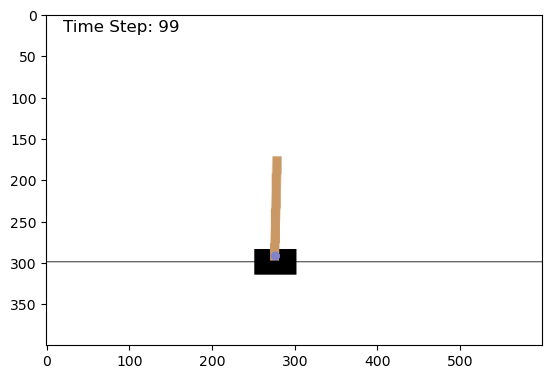

In [6]:
# For Google Colaboratory
if 'google.colab' in sys.modules:
    import gnwrapper
    env = gnwrapper.Monitor(gym.make('CartPole-v1', render_mode="rgb_array"), directory="./") 
    env._max_episode_steps = 5000
    # env._max_episode_steps = 100 # DEBUG
    state, _ = env.reset()
    for t in range(env._max_episode_steps):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)
        action = Categorical(net_policy(state_pytorch)).sample()
        state, _, done, _ = env.step(action.item()) 
        # env.render() # no need this line with Monitor/gnwrapper; it records automatically
        if done:
            print(f"Episode finished at step {t}")
            break
    env.display()

# For Local Environment
else: 
    env = gym.make('CartPole-v1', render_mode="rgb_array")
    env._max_episode_steps = 5000
    env._max_episode_steps = 100 # DEBUG
    state = env.reset()[0]
    img = plt.imshow(env.render()) # Setup the plot
    time_text = plt.text(20, 20, '', color='black', fontsize=12)
    for t in range(env._max_episode_steps):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)
        action = Categorical(net_policy(state_pytorch)).sample()
        state, _, done, _, _ = env.step(action.item()) 
        img.set_data(env.render()) 
        time_text.set_text(f'Time Step: {t}')
        display.display(plt.gcf())
        display.clear_output(wait=True)
        if done:
            break
        env.close()
    print(f"Finished at step {t}")

        